In [32]:
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langgraph.checkpoint.memory import MemorySaver
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from typing import Optional, TypedDict, Annotated
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_text_splitters import RecursiveCharacterTextSplitter
from pydantic import BaseModel, Field

In [33]:
embeddings = GoogleGenerativeAIEmbeddings(
    model="gemini-embedding-2-preview", 
    output_dimensionality=768
)

In [34]:
llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash")

In [35]:
UPPER_THRES = 0.8
LOWER_THRES = 0.3

In [36]:
search_tool = DuckDuckGoSearchRun()

In [30]:
file_path = "book.pdf"
loader = PyPDFLoader(file_path)
documents = loader.load()

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200, separators=["\n\n", "\n", " ", ""])
chunks = text_splitter.split_documents(documents)

vectorstore = FAISS.from_documents(chunks, embeddings)

retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 4})

In [31]:
from typing import Literal


class State(TypedDict):
    question:str
    docs:list[Document]

    good_docs: list[Document]
    verdict: Literal["correct" , "incorrect" , "ambiguous"]
    reason_for_verdict: str
    strips: list[str]
    kept_strips: list[str]
    refined_context: str

    web_docs: list[Document]
    
    answer:str

In [37]:
def retrieve(state: State):
    """
    Retrieve relevant documents based on the question.
    """
    query = state["question"]
    retrieved_docs = retriever.invoke(query)
    return {"docs": retrieved_docs}
    

In [38]:
class DocScorer(BaseModel):
    score: float = Field(..., ge=0.0, le=1.0, description="Score between 0 and 1")
    reason: str = Field(..., description="Reason for the score")

In [39]:
doc_eval_prompt = ChatPromptTemplate.from_messages([
    ("system", 
    """
    You are a strict document evaluator. You will be given a question and a document. Your task is to evaluate the document's relevance to the question and provide a score between 0 and 1, along with a reason for your score.
    """
    ),
    ("human", 
    """
    Question: {question}
    Document: {document}
    """)
])
eval_llm = llm.with_structured_output(DocScorer)
evaluator_chain = doc_eval_prompt | eval_llm

In [40]:
def evaluate_docs(state: State):
    """
    Evaluate the retrieved documents and filter them based on the score.
    """
    question = state["question"]
    docs = state["docs"]
    
    good_docs = []
    verdict = "incorrect"
    reason_for_verdict = ""
    
    for doc in docs:
        evaluation = evaluator_chain.invoke({"question": question, "document": doc.page_content})
        if evaluation.score >= UPPER_THRES:
            verdict = "correct"
            good_docs.append(doc)
        elif evaluation.score <= LOWER_THRES:
            continue
        else:
            if verdict != "correct":
                verdict = "ambiguous"
            good_docs.append(doc)

    
    if verdict == "correct":
        reason_for_verdict = "At least one document is highly relevant."
    elif verdict == "ambiguous":
        reason_for_verdict = "Some documents are ambiguous."
    else:
        reason_for_verdict = "No documents are relevant."
    
    return {
        "good_docs": good_docs,
        "verdict": verdict,
        "reason_for_verdict": reason_for_verdict
    }


In [57]:
class RewriteQuery(BaseModel):
    query: str = Field(..., description="ELaborate, more clear, and specific version of the original question to use for web search.")

prompt_rewrite_query = ChatPromptTemplate.from_messages([
    ("system",
    """
    Reformulate the user's question to be more specific and clear for web search. The reformulated question should be detailed and unambiguous.
    - Keep the context of the original question in mind.
    - Avoid using vague terms or pronouns that could lead to ambiguity.
    Do NOT answer the question. Only reformulate it for web search.
    - Return JSON with the key 'query' containing the reformulated question.
    """
    ),
    ("human",
    """
    Original Question: {question}
    """)
])

def rewrite_query(state: State):
    """
    Rewrite the user's question to be more specific and clear for web search.
    """
    question = state["question"]
    rewrite_chain = prompt_rewrite_query | llm.with_structured_output(RewriteQuery)
    rewritten_query = rewrite_chain.invoke({"question": question})
    return {"rewritten_query": rewritten_query.query}

In [41]:
def web_search(state: State):
    """
    Perform a web search if the retrieved documents are not sufficient.
    """
    query = state["question"]
    web_docs = []
    search_results = search_tool.invoke(query)
    results = search_results.split("]")
    for result in results:
        if result.startswith("["):
            web_docs.append(Document(page_content=result[1:].strip()))
    return {"web_docs": web_docs}

In [42]:
import re
def decompose_to_strips(text:str)->list[str]:
    text = re.sub(r'\s+', ' ', text).strip()
    sentences = re.split(r'(?<=[.!?]) +', text)
    return [s.strip() for s in sentences if len(s.strip())>20]

In [43]:
class KeepStrip(BaseModel):
    keep: bool = Field(..., description="Whether to keep the strip or not")


filter_prompt= ChatPromptTemplate.from_messages([
    (
        "system",
        """"You are a strict relevance filter.\n
        You will be given a list of text strips and a question.\n"
        "Return keep=true if the sentence is relevant to the question, otherwise return keep=false.\n"
        Use only the sentence and output JSON only
        """
    ),
    (
        "human",
        """Question: {question}\n
        Sentence: {sentence}\n
        Output JSON only, no explanations.
        """
    )
])

llm_filter = llm.with_structured_output(KeepStrip)
filter_chain = filter_prompt | llm_filter

In [44]:
# REFINING (Decompose -> Filter -> Recompose)
def refine_context(state: State):
    """
    Refine the context by decomposing the retrieved documents into strips, filtering them based on relevance to the question, and recomposing the relevant strips into a refined context.
    """
    used_docs = state["good_docs"] if state["verdict"] in ["correct"] else state["web_docs"]
    context = "\n\n".join([doc.page_content for doc in used_docs]).strip()
    strips = decompose_to_strips(context)
    filtered_strips = [strip for strip in strips if filter_chain.invoke({"question": state["question"], "sentence": strip}).keep]

    refined_context = "\n".join(filtered_strips)

    return {
        "strips": strips,
        "kept_strips": filtered_strips,
        "refined_context": refined_context
    }

In [45]:
def generate_answer(state: State):
    """
    Generate an answer to the question based on the refined context.
    """
    final_chain = answer_prompt | llm
    res = final_chain.invoke({"refined_context": state["refined_context"], "question": state["question"]})
    return {"answer": res.text}

In [46]:
answer_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant that answers questions based on the provided context."),
    ("human", "Context: {refined_context}\n\nQuestion: {question}")
])

In [60]:
def fail_node(state:State):
    return {"answer" : f"FAIL: {state['reason_for_verdict']}"}

def ambiguous_node(state:State):
    return {"answer" : f"AMBIGUOUS: {state['reason_for_verdict']}"}

def check_verdict(state: State):
    """
    Check the verdict and route to the appropriate node based on the evaluation of the documents.
    """
    if state["verdict"] == "correct":
        return "refine_context"
    elif state["verdict"] == "ambiguous":
        return "ambiguous_node"
    else:
        return "rewrite_query"

In [58]:
graph = StateGraph(State)

In [59]:
#add_nodes
graph.add_node("retrieve", retrieve)
graph.add_node("evaluate_docs", evaluate_docs)
graph.add_node("refine_context", refine_context)
graph.add_node("generate_answer", generate_answer)
graph.add_node("web_search", web_search)
graph.add_node("rewrite_query", rewrite_query)
graph.add_node("ambiguous_node", ambiguous_node)

In [61]:
graph.add_edge(START, "retrieve")
graph.add_edge("retrieve", "evaluate_docs")
graph.add_conditional_edges("evaluate_docs", check_verdict)
graph.add_edge("rewrite_query", "web_search")
graph.add_edge("web_search", "refine_context")
graph.add_edge("refine_context", "generate_answer")
graph.add_edge("generate_answer", END)
graph.add_edge("ambiguous_node", END)

In [62]:
workflow = graph.compile(checkpointer=MemorySaver())

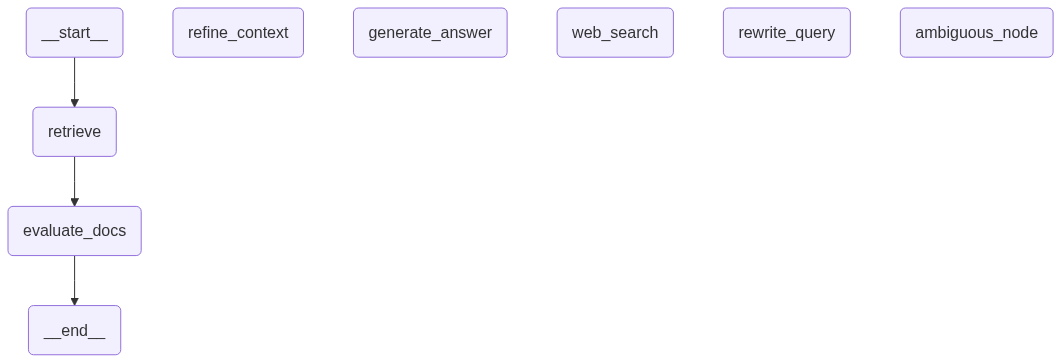

In [63]:
from IPython.display import Image, display
display(Image(workflow.get_graph().draw_mermaid_png()))

In [55]:
config = {"configurable" :  { "thread_id" : "harshit_thread_1"}}

In [31]:
while True:
    question = input("You>")
    end_words = ['exit', 'quit', 'bye', 'goodbye', '0']
    if question.lower() in end_words:
        break

    initial_state = {"question": question}
    result = workflow.invoke(initial_state, config=config)
    print("Answer:", result["answer"])

In [32]:
print(f"Refined context: {result['refined_context']}")

NameError: name 'result' is not defined

In [56]:
question = "What is the main theme of the book?"
initial_state = {"question": question}
result = workflow.invoke(initial_state, config=config)

GoogleAPIError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}

In [ ]:
print("Verdict:", result["verdict"])
print("Reason for verdict:", result["reason_for_verdict"])